<a href="https://colab.research.google.com/github/Shree1785/CSL701-CE49-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bhagyashree Shrikrishna Wagle CE3 CE49

Machine Learning Experiment No. 5

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import BaggingClassifier

# Load dataset
file_path = "diabetes.csv"
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape of dataset:
(768, 9)

Column names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Data types:
Pregnancies                   int64
Glucose                       int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages:
Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64


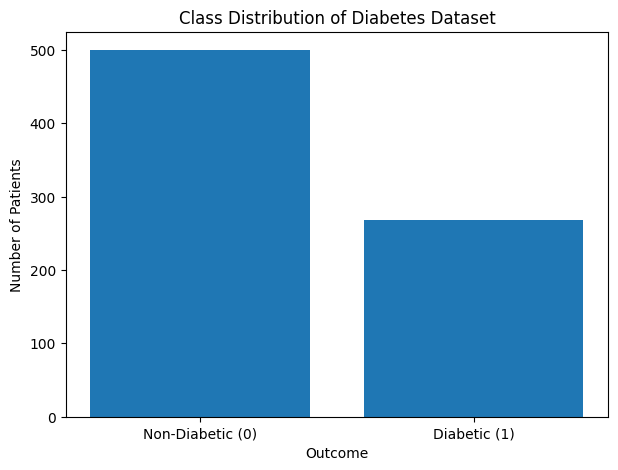

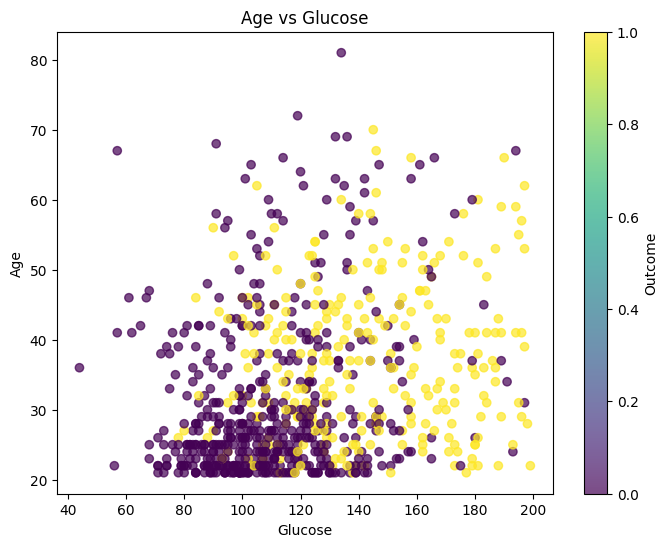


Explanation:

A single linear decision boundary may not be sufficient for
diabetes prediction because diabetes depends on multiple
features such as Glucose, BMI, Age, BloodPressure and
DiabetesPedigreeFunction.

The relationship between these features and diabetes outcome
can be non-linear. Decision Trees can handle such non-linear
relationships better than a simple linear boundary.



In [ ]:
# TASK 2: Class distribution and visualization

# Count each class
class_counts = df["Outcome"].value_counts().sort_index()

print("Class Counts:")
print(class_counts)

# Calculate percentages
class_percentages = (class_counts / len(df)) * 100

print("\nClass Percentages:")
print(class_percentages)

# Bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    class_counts.values
)

plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.title("Class Distribution of Diabetes Dataset")
plt.show()


# Age vs Glucose scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Glucose"],
    df["Age"],
    c=df["Outcome"],
    alpha=0.7
)

plt.xlabel("Glucose")
plt.ylabel("Age")
plt.title("Age vs Glucose")
plt.colorbar(label="Outcome")
plt.show()


print("""
Explanation:

A single linear decision boundary may not be sufficient for
diabetes prediction because diabetes depends on multiple
features such as Glucose, BMI, Age, BloodPressure and
DiabetesPedigreeFunction.

The relationship between these features and diabetes outcome
can be non-linear. Decision Trees can handle such non-linear
relationships better than a simple linear boundary.
""")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# TASK 3: Handle invalid zero values

# Features where zero is considered an invalid/missing value
invalid_zero_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Number of zero values before treatment:")

for column in invalid_zero_features:
    print(
        column,
        ":",
        (df[column] == 0).sum()
    )


# Replace zero values with NaN
df[invalid_zero_features] = df[
    invalid_zero_features
].replace(0, np.nan)


# Replace missing values using median
for column in invalid_zero_features:

    df[column] = df[column].fillna(
        df[column].median()
    )


print("\nMissing values after treatment:")

print(df.isnull().sum())

Number of zero values before treatment:
Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing values after treatment:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# TASK 4: Train-test split

# Separate input features
X = df.iloc[:, :8]

# Separate target
y = df["Outcome"]


print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)


print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

Training data shape:
(614, 8)

Testing data shape:
(154, 8)

Training target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
# TASK 5: Generate Bootstrap Samples

def get_bootstrap_sample(X, y):

    # Number of samples
    n_samples = len(X)

    # Random sampling with replacement
    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    # Create bootstrap sample
    X_bootstrap = X.iloc[
        indices
    ].reset_index(drop=True)

    y_bootstrap = y.iloc[
        indices
    ].reset_index(drop=True)

    return X_bootstrap, y_bootstrap, indices


# Generate one bootstrap sample
X_bootstrap, y_bootstrap, indices = get_bootstrap_sample(
    X_train,
    y_train
)


print("Original training samples:")
print(len(X_train))

print("\nBootstrap samples:")
print(len(X_bootstrap))

print("\nFirst 20 selected indices:")
print(indices[:20])


# Find duplicate samples
unique_indices = len(np.unique(indices))

duplicate_samples = (
    len(indices) - unique_indices
)

print("\nUnique samples selected:")
print(unique_indices)

print("\nDuplicate selections:")
print(duplicate_samples)


# Find Out-of-Bag samples
oob_indices = list(
    set(range(len(X_train))) -
    set(indices)
)

print("\nOut-of-Bag samples:")
print(len(oob_indices))

Original training samples:
614

Bootstrap samples:
614

First 20 selected indices:
[574 459 462  41 343  11 467 468 577 244 537 523 222  69 361  34 599 503
 235 314]

Unique samples selected:
391

Duplicate selections:
223

Out-of-Bag samples:
223


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# TASK 6: Train 50 Decision Trees using Bootstrap Samples

B = 50

ensemble = []


for i in range(B):

    # Generate bootstrap sample
    X_bootstrap, y_bootstrap, _ = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=i
    )

    # Train Decision Tree
    model.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Add model to ensemble
    ensemble.append(model)


print("Number of Decision Trees in Ensemble:")
print(len(ensemble))

Number of Decision Trees in Ensemble:
50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
# TASK 7: Custom Bagging Prediction

def custom_bagging_predict(ensemble, X_test):

    all_predictions = []


    # Get predictions from every tree
    for model in ensemble:

        predictions = model.predict(
            X_test
        )

        all_predictions.append(
            predictions
        )


    # Convert predictions to NumPy array
    all_predictions = np.array(
        all_predictions
    )


    final_predictions = []


    # Majority voting
    for i in range(
        all_predictions.shape[1]
    ):

        sample_predictions = (
            all_predictions[:, i]
        )

        counts = np.bincount(
            sample_predictions.astype(int)
        )

        final_class = np.argmax(
            counts
        )

        final_predictions.append(
            final_class
        )


    return np.array(
        final_predictions
    )


# Generate predictions
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


print("First 20 Bagging Predictions:")
print(y_pred_bagging[:20])

First 20 Bagging Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.


Single Decision Tree
Accuracy  : 0.8116883116883117
Precision : 0.7450980392156863
Recall    : 0.7037037037037037
F1 Score  : 0.7238095238095238

Confusion Matrix:
[[87 13]
 [16 38]]

Custom Bagging
Accuracy  : 0.8831168831168831
Precision : 0.8461538461538461
Recall    : 0.8148148148148148
F1 Score  : 0.8301886792452831

Confusion Matrix:
[[92  8]
 [10 44]]


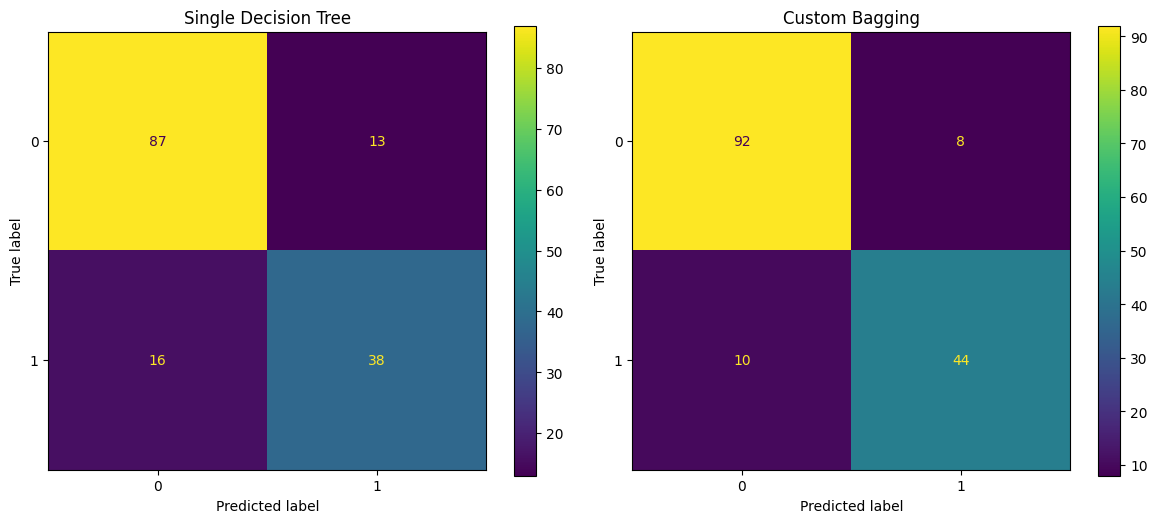

In [ ]:
# TASK 8: Compare Single Decision Tree and Custom Bagging


# Create a single Decision Tree
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)


# Train single Decision Tree
single_tree.fit(
    X_train,
    y_train
)


# Predictions from single tree
y_pred_tree = single_tree.predict(
    X_test
)


# Predictions from Bagging
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# Evaluation function
def evaluate_model(
    name,
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )


    print("\n" + "=" * 50)

    print(name)

    print("=" * 50)

    print(
        "Accuracy  :",
        accuracy
    )

    print(
        "Precision :",
        precision
    )

    print(
        "Recall    :",
        recall
    )

    print(
        "F1 Score  :",
        f1
    )


    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )


# Evaluate Single Decision Tree
evaluate_model(
    "Single Decision Tree",
    y_test,
    y_pred_tree
)


# Evaluate Custom Bagging
evaluate_model(
    "Custom Bagging",
    y_test,
    y_pred_bagging
)


# Plot confusion matrices
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


ConfusionMatrixDisplay(
    confusion_matrix(
        y_test,
        y_pred_tree
    )
).plot(
    ax=axes[0]
)

axes[0].set_title(
    "Single Decision Tree"
)


ConfusionMatrixDisplay(
    confusion_matrix(
        y_test,
        y_pred_bagging
    )
).plot(
    ax=axes[1]
)

axes[1].set_title(
    "Custom Bagging"
)


plt.tight_layout()

plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree AUC:
0.7868518518518519

Custom Bagging AUC:
0.9554629629629628


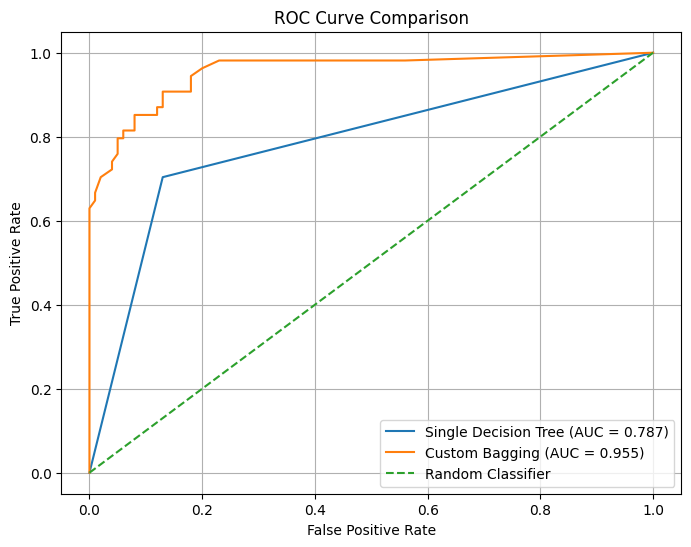

In [ ]:
# TASK 9: ROC Curve and AUC


# Probability predictions from Single Decision Tree
tree_probabilities = (
    single_tree.predict_proba(
        X_test
    )[:, 1]
)


# Store probability predictions
all_probabilities = []


# Get probabilities from all 50 trees
for model in ensemble:

    probabilities = (
        model.predict_proba(
            X_test
        )[:, 1]
    )

    all_probabilities.append(
        probabilities
    )


# Convert to NumPy array
all_probabilities = np.array(
    all_probabilities
)


# Average probabilities
bagging_probabilities = np.mean(
    all_probabilities,
    axis=0
)


# ROC curve for Single Tree
tree_fpr, tree_tpr, _ = roc_curve(
    y_test,
    tree_probabilities
)


# ROC curve for Bagging
bag_fpr, bag_tpr, _ = roc_curve(
    y_test,
    bagging_probabilities
)


# Calculate AUC
tree_auc = roc_auc_score(
    y_test,
    tree_probabilities
)


bag_auc = roc_auc_score(
    y_test,
    bagging_probabilities
)


print("Single Decision Tree AUC:")
print(tree_auc)

print("\nCustom Bagging AUC:")
print(bag_auc)


# Plot ROC curves
plt.figure(figsize=(8, 6))


plt.plot(
    tree_fpr,
    tree_tpr,
    label=f"Single Decision Tree (AUC = {tree_auc:.3f})"
)


plt.plot(
    bag_fpr,
    bag_tpr,
    label=f"Custom Bagging (AUC = {bag_auc:.3f})"
)


# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.grid()

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [ ]:
# TASK 10: Validate with Scikit-learn BaggingClassifier


# Create Decision Tree base estimator
base_estimator = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)


# Handle different versions of scikit-learn
try:

    sklearn_bagging = BaggingClassifier(
        estimator=base_estimator,
        n_estimators=50,
        random_state=42
    )

except TypeError:

    sklearn_bagging = BaggingClassifier(
        base_estimator=base_estimator,
        n_estimators=50,
        random_state=42
    )


# Train sklearn Bagging model
sklearn_bagging.fit(
    X_train,
    y_train
)


# Make predictions
y_pred_sklearn = sklearn_bagging.predict(
    X_test
)


# Calculate accuracy
sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)


print("Scikit-learn Bagging Accuracy:")
print(sklearn_accuracy)


# Confusion Matrix
print("\nScikit-learn Bagging Confusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_sklearn
    )
)


# Calculate other metrics
sklearn_precision = precision_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)

sklearn_recall = recall_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)

sklearn_f1 = f1_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)


print("\nPrecision:")
print(sklearn_precision)

print("\nRecall:")
print(sklearn_recall)

print("\nF1 Score:")
print(sklearn_f1)


# Final comparison
single_tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

custom_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)


print("\n")
print("=" * 50)
print("FINAL ACCURACY COMPARISON")
print("=" * 50)

print(
    "Single Decision Tree :",
    single_tree_accuracy
)

print(
    "Custom Bagging       :",
    custom_accuracy
)

print(
    "Sklearn Bagging      :",
    sklearn_accuracy
)

Scikit-learn Bagging Accuracy:
0.8831168831168831

Scikit-learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]

Precision:
0.8333333333333334

Recall:
0.8333333333333334

F1 Score:
0.8333333333333334


FINAL ACCURACY COMPARISON
Single Decision Tree : 0.8116883116883117
Custom Bagging       : 0.8831168831168831
Sklearn Bagging      : 0.8831168831168831


## Conclusion

In this experiment, Bagging (Bootstrap Aggregating) was implemented
from scratch using 50 fully-grown Decision Trees.

Bootstrap samples were generated by sampling the training dataset
with replacement. Each Decision Tree was trained on a different
bootstrap sample, creating diversity among the individual models.

The predictions of all the Decision Trees were combined using
majority voting to obtain the final Bagging prediction.

The performance of a single Decision Tree and the custom Bagging
classifier was compared using Accuracy, Precision, Recall, F1 Score,
Confusion Matrix and ROC-AUC.

Bagging generally helps reduce the variance of a single Decision Tree
and produces a more stable and robust model. The use of multiple
different bootstrap samples allows the trees to make different
predictions, while majority voting combines their decisions.

ROC curves and AUC were also used to compare the classification
performance of the models.

For diabetes prediction, Recall is particularly important because a
False Negative means that a diabetic patient may be incorrectly
classified as non-diabetic. Therefore, a model with good Recall can
help identify more patients who may need further medical examination.

Thus, Bagging demonstrates the effectiveness of ensemble learning by
combining multiple Decision Trees to improve the stability and
reliability of predictions.